In [5]:
import cx_Oracle
# Step 1: Initialize Oracle Client (ONLY once)
cx_Oracle.init_oracle_client(lib_dir=r"C:\Users\SHRAVANI\Downloads\instantclient-basic-windows.x64-23.7.0.25.01\instantclient_23_7")
dsn = cx_Oracle.makedsn("LAPTOP-7LSCVLT9", 1521, service_name="xe")
conn = cx_Oracle.connect(user="System", password="12345678", dsn=dsn)


In [6]:
import pandas as pd
df = pd.read_sql("SELECT * FROM SALES_data", conn)
print(df)


C:\Users\SHRAVANI\anaconda3\lib\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


      ID  ORDER_ID  ORDER_DATE  PRODUCT_ID PRODUCT_NAME    AMOUNT  QUANTITY
0      1         1   8/11/2017           1    Bookcases    261.96         2
1      2         2   8/11/2017           2       Chairs    731.94         4
2      3         3   12/6/2017           3       Labels     14.62         8
3      4         4  11/10/2016           4       Tables  957.5775         1
4      5         5  11/10/2016           5      Storage    22.368         2
..   ...       ...         ...         ...          ...       ...       ...
195  196       196  21/03/2015         196          Art     7.408         7
196  197       197  21/03/2015         197          Art     6.048         1
197  198       198   6/11/2018         198      Storage     46.26         3
198  199       199    6/7/2018         199      Binders     2.946         9
199  200       200    6/7/2018         200        Paper      None         3

[200 rows x 7 columns]


C:\Users\SHRAVANI\AppData\Local\Temp\ipykernel_23744\1315196462.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql("SELECT * FROM SALES_data", conn)


In [9]:
import pandas as pd
query = """
    SELECT 
        product_name
        , 
        SUM(quantity) AS total_qty, 
        SUM(quantity * amount) AS revenue
    FROM 
        SALES_data
    GROUP BY 
        product_name
"""

# Fetch results into a DataFrame
df = pd.read_sql(query, conn)

# Display result
print(df)


   PRODUCT_NAME  TOTAL_QTY     REVENUE
0        Tables         25  23826.6195
1         Paper        115   5785.3780
2     Bookcases         14  15675.0876
3        Labels         24    422.2200
4       Binders        163   7032.4980
5           Art        105   3894.0940
6        Phones        116  48942.6560
7   Accessories         81  10636.7560
8     Envelopes         53   3041.6080
9       Storage        107  19720.7000
10       Chairs         92  54454.3530
11     Machines          7  57119.6640
12   Appliances         62  13776.5180
13  Furnishings         92   6544.5620
14    Fasteners         19    498.2800
15     Supplies         16    654.0800


C:\Users\SHRAVANI\AppData\Local\Temp\ipykernel_23744\891228824.py:15: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


In [12]:
print(df.columns)


Index(['PRODUCT_NAME', 'TOTAL_QTY', 'REVENUE'], dtype='object')


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16 entries, 0 to 15
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PRODUCT_NAME  16 non-null     object 
 1   TOTAL_QTY     16 non-null     int64  
 2   REVENUE       16 non-null     float64
dtypes: float64(1), int64(1), object(1)
memory usage: 512.0+ bytes


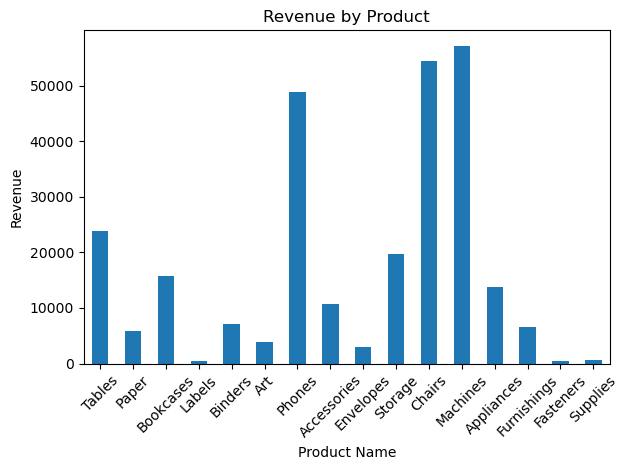

In [14]:
import matplotlib.pyplot as plt

df.plot(kind='bar', x='PRODUCT_NAME', y='REVENUE', legend=False)
plt.xlabel('Product Name')
plt.ylabel('Revenue')
plt.title('Revenue by Product')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
